FLIPKART SALES

In [4]:
# Library Importation
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats                  # Statistical analysis package
from scipy.stats import ttest_ind        # Compare 2 groups
from scipy.stats import ttest_1samp      # Compare sample mean with fixed value
from scipy.stats import f_oneway         # Compare more than 2 groups
from scipy.stats import chi2_contingency # Check relationship between 2 variables

In [5]:
df = pd.read_csv("flipkart_sales.csv")

In [6]:
df.head()

,Order_ID,Product_ID,Product_Name,Category,Brand,Actual_Price,Rating,Rating_Count,Customer_Age,Gender,Region,Payment_Method,Delivery_Days,Return_Status,Review_Sentiment,Discount_Percentage,Discounted_Price
0,FK100000,P1000,Product_0,Beauty,Philips,5921.68,4.3,2796,39.0,Male,South,COD,6.0,Returned,Neutral,7,5507.16
1,FK100001,P1001,Product_1,Grocery,Boat,4016.65,3.8,3801,38.0,Male,South,UPI,6.0,Returned,Positive,67,1325.49
2,FK100002,P1002,Product_2,Home,Philips,5071.86,4.6,1298,43.0,Female,North,UPI,2.0,Not Returned,Positive,68,1623.00
3,FK100003,P1003,Product_3,Grocery,Philips,8196.13,4.2,3881,57.0,Female,North,Card,2.0,Returned,Positive,66,2786.68
4,FK100004,P1004,Product_4,Grocery,Adidas,5477.75,3.9,1816,38.0,Male,North,COD,2.0,Not Returned,Negative,10,4929.98


In [7]:
df.tail()

,Order_ID,Product_ID,Product_Name,Category,Brand,Actual_Price,Rating,Rating_Count,Customer_Age,Gender,Region,Payment_Method,Delivery_Days,Return_Status,Review_Sentiment,Discount_Percentage,Discounted_Price
1015,FK100899,P1899,Product_899,Home,Samsung,5053.28,NaN,1647,NaN,Female,West,UPI,7.0,Not Returned,Positive,32,3436.23
1016,FK100280,P1280,Product_280,Beauty,Philips,5449.74,3.9,4208,53.0,Male,West,COD,1.0,Not Returned,Positive,42,3160.85
1017,FK100883,P1883,Product_883,Home,Puma,6900.14,3.5,4096,38.0,Female,North,UPI,7.0,Not Returned,Negative,54,3174.06
1018,FK100761,P1761,Product_761,Fashion,Boat,4704.83,3.6,1549,31.0,Female,West,COD,9.0,Not Returned,Positive,46,2540.61
1019,FK100319,P1319,Product_319,Beauty,NaN,10362.87,3.9,1485,32.0,Female,South,Card,8.0,Returned,Neutral,22,8083.04


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Order_ID             1020 non-null   object 
 1   Product_ID           1020 non-null   object 
 2   Product_Name         1020 non-null   object 
 3   Category             1020 non-null   object 
 4   Brand                948 non-null    object 
 5   Actual_Price         1020 non-null   float64
 6   Rating               947 non-null    float64
 7   Rating_Count         1020 non-null   int64  
 8   Customer_Age         948 non-null    float64
 9   Gender               1020 non-null   object 
 10  Region               1020 non-null   object 
 11  Payment_Method       1020 non-null   object 
 12  Delivery_Days        949 non-null    float64
 13  Return_Status        1020 non-null   object 
 14  Review_Sentiment     1020 non-null   object 
 15  Discount_Percentage  1020 non-null   i

In [9]:
df.shape

(1020, 17)

In [10]:
df.columns

Index(['Order_ID', 'Product_ID', 'Product_Name', 'Category', 'Brand',
       'Actual_Price', 'Rating', 'Rating_Count', 'Customer_Age', 'Gender',
       'Region', 'Payment_Method', 'Delivery_Days', 'Return_Status',
       'Review_Sentiment', 'Discount_Percentage', 'Discounted_Price'],
      dtype='object')

In [11]:
df.dtypes

,0
Order_ID,object
Product_ID,object
Product_Name,object
Category,object
Brand,object
Actual_Price,float64
Rating,float64
Rating_Count,int64
Customer_Age,float64
Gender,object


In [12]:
df.isnull().sum()

,0
Order_ID,0
Product_ID,0
Product_Name,0
Category,0
Brand,72
Actual_Price,0
Rating,73
Rating_Count,0
Customer_Age,72
Gender,0


In [13]:
df.describe()

,Actual_Price,Rating,Rating_Count,Customer_Age,Delivery_Days,Discount_Percentage,Discounted_Price
count,1020.000000,947.000000,1020.000000,948.000000,949.000000,1020.000000,1020.000000
mean,6252.956912,4.005597,2735.330392,40.404008,5.167545,37.787255,3256.948833
std,8821.974373,0.486086,2322.623436,13.116095,3.692900,18.094584,1878.510528
min,100.000000,2.500000,21.000000,18.000000,1.000000,5.000000,34.000000
25%,3556.212500,3.700000,1271.500000,30.000000,3.000000,22.000000,1942.767500
50%,5189.295000,4.000000,2549.000000,40.000000,5.000000,38.000000,2969.665000
75%,6900.365000,4.300000,3968.000000,51.000000,7.000000,53.000000,4335.325000
max,103556.800000,5.000000,20000.000000,64.000000,30.000000,69.000000,10304.340000


In [14]:
print("Mean of Rating:")

rating_mean = df['Rating'].mean()

print(rating_mean)



Mean of Rating:
4.005596620908131


Notes:

The mean rating is 4.003, indicating good customer satisfaction and a positive customer experience. Most customers are satisfied with the products and services provided.

In [15]:
print("Median of Delivery Days:")

delivery_median = df['Delivery_Days'].median()

print(delivery_median)



Median of Delivery Days:
5.0


Notes:

The median delivery time is 5 days, indicating that most customer orders are delivered within 5 days and delivery performance is reasonably consistent.

In [16]:
brand_count = df['Brand'].value_counts()

print("Most repeated brand:")

print(brand_count.head(1))

Most repeated brand:
Brand
Puma    132
Name: count, dtype: int64


Notes:

Boat is the most repeated brand with 137 occurrences, indicating high customer preference and strong demand among customers.

In [17]:
# Fill null values in Brand column using mode value

df['Brand'].fillna(137, inplace=True)

print(df['Brand'].isnull().sum())

0


/tmp/ipykernel_6025/394973045.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Brand'].fillna(137, inplace=True)


In [18]:
# Shape before removing duplicates
print("Before:",df.shape)

Before: (1020, 17)


In [19]:
# Find duplicates
print("Duplicate rows:",df.duplicated().sum())

Duplicate rows: 20


In [20]:
# Remove duplicates
df.drop_duplicates(inplace=True)

In [21]:
# Shape after removing duplicates
print("After:",df.shape)

After: (1000, 17)


In [22]:
# Fill null values using Forward Fill
df.fillna(method='ffill', inplace=True)

print(df.isnull().sum())

Order_ID               0
Product_ID             0
Product_Name           0
Category               0
Brand                  0
Actual_Price           0
Rating                 0
Rating_Count           0
Customer_Age           0
Gender                 0
Region                 0
Payment_Method         0
Delivery_Days          0
Return_Status          0
Review_Sentiment       0
Discount_Percentage    0
Discounted_Price       0
dtype: int64


/tmp/ipykernel_6025/3428479103.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [23]:
# Skewness and Kurtosis
numerical_columns = ['Actual_Price',
                     'Discounted_Price',
                     'Customer_Age',
                     'Rating',
                     'Delivery_Days']

print("Skewness Values:")
print(df[numerical_columns].skew())

print("\nKurtosis Values:")
print(df[numerical_columns].kurt())

Skewness Values:
Actual_Price        8.039592
Discounted_Price    0.732121
Customer_Age        0.063695
Rating             -0.133094
Delivery_Days       3.178859
dtype: float64

Kurtosis Values:
Actual_Price        73.023683
Discounted_Price     0.445791
Customer_Age        -1.110916
Rating              -0.202033
Delivery_Days       19.387965
dtype: float64


INTERQUARTILE RANGE

In [24]:
# IQR method for remove outlier
Q1 = df['Actual_Price'].quantile(0.25)

Q3 = df['Actual_Price'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - (1.5 * IQR)

upper_limit = Q3 + (1.5 * IQR)

print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

# Remove outliers
df = df[(df['Actual_Price'] >= lower_limit) &
        (df['Actual_Price'] <= upper_limit)]

print("Shape after removing outliers:")
print(df.shape)

Lower Limit: -1505.0874999999987
Upper Limit: 11938.992499999998
Shape after removing outliers:
(981, 17)


T-TEST (INDEPENDENT 2-SAMPLE TEST)

In [25]:
male=df[df['Gender']=="Male"]['Actual_Price']

female=df[df['Gender']=="Female"]['Actual_Price']

t_stat,p_value=ttest_ind(male,female)

print("T-statistic:",t_stat)

print("P-value:",p_value)

if p_value<0.05:
    print("Male and Female spending differs")
else:
    print("No significant difference")

# Accept Null Hypothesis

T-statistic: -0.47092089996535225
P-value: 0.6378021309329212
No significant difference


Z-TEST (ONE-SAMPLE TEST)

In [26]:
import numpy as np
from scipy.stats import norm # Normal distribution function to calculate p-value

# Hypothesized mean
population_mean = 4

# Sample values
sample_mean = df['Rating'].mean()
sample_std = df['Rating'].std()
n = len(df['Rating'])

# Calculate Z-score
z_score = (sample_mean - population_mean) / (sample_std / np.sqrt(n))

print("Z-score:", z_score)

# Calculate p-value
p_value = 2 * (1 - norm.cdf(abs(z_score))) # Cumulative distribution function

print("P-value:", p_value)

# Decision
if p_value < 0.05:
    print("Reject Null Hypothesis")
else:
    print("Accept Null Hypothesis")

Z-score: 0.19795838626532616
P-value: 0.8430776223141085
Accept Null Hypothesis


ANNOVA TEST

In [27]:
north=df[df['Region']=="North"]['Delivery_Days']

south=df[df['Region']=="South"]['Delivery_Days']

east=df[df['Region']=="East"]['Delivery_Days']

west=df[df['Region']=="West"]['Delivery_Days']

f_stat,p_value=f_oneway(north,south,east,west)

print("F-statistic:",f_stat)

print("P-value:",p_value)

F-statistic: 0.2123934095556786
P-value: 0.8878431548241734


CHI-SQUARED TEST

In [28]:
contingency_table=pd.crosstab(
    df['Return_Status'],
    df['Payment_Method']
)

chi2,p,dof,expected=chi2_contingency(contingency_table)

print("Chi-square:",chi2)

print("P-value:",p)

Chi-square: 0.7498345622658651
P-value: 0.687346132932884


DATA VISUALIZATION

1.BAR CHART

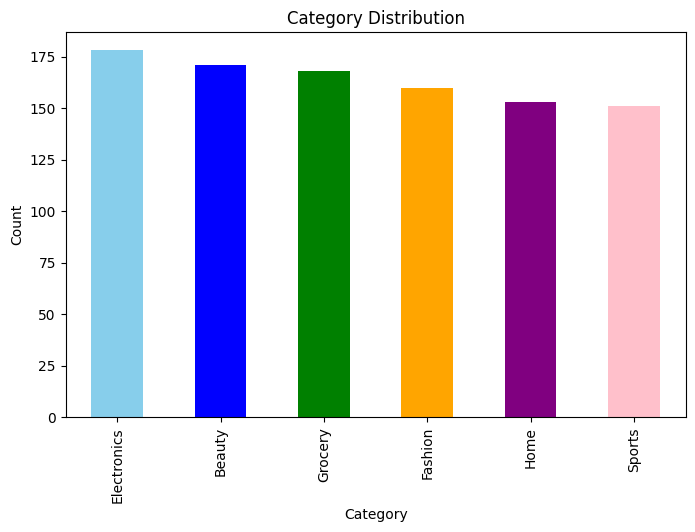

In [30]:
import matplotlib.pyplot as plt

# Categorical count
plt.figure(figsize=(8,5))

colors=['skyblue','blue','green','orange',
         'purple','pink','yellow','brown']

df['Category'].value_counts().plot(kind='bar',color=colors)

plt.title("Category Distribution")

plt.savefig("Category Distribution")

plt.xlabel("Category")

plt.ylabel("Count")

plt.show()

Insights:

 Some categories have higher counts, indicating greater customer demand and popularity.
 Categories with lower counts may have lower customer interest or fewer products available.

Recommendations:

 Focus marketing efforts on high-performing categories to increase sales.
 Improve or promote low-performing categories through offers and advertisements.
 Analyze customer preferences to maintain a balanced product portfolio.


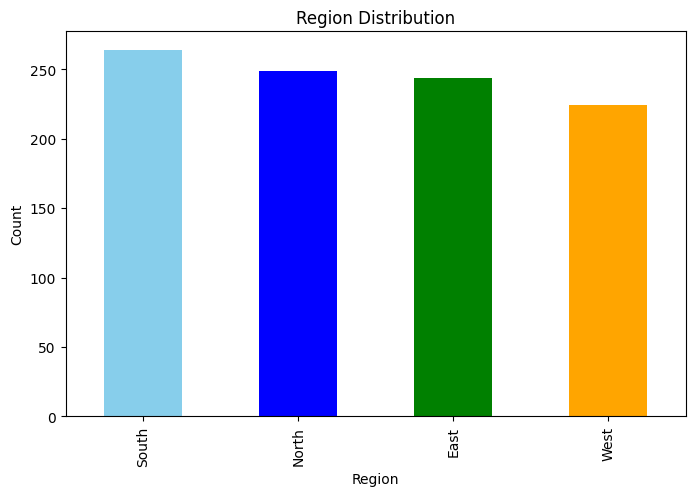

In [37]:
# Regional count
plt.figure(figsize=(8,5))

colors=['skyblue','blue','green','orange',
         'purple','pink','yellow','brown']

df['Region'].value_counts().plot(kind='bar', color=colors)

plt.title("Region Distribution")

plt.savefig("Region Distribution")

plt.xlabel("Region")

plt.ylabel("Count")

plt.show()

Insights:

The region with the highest count indicates a larger customer base and stronger market presence.
Regions with lower counts may have lower customer engagement or fewer sales opportunities.

Recommendations:

Focus more marketing campaigns on high-performing regions to maximize revenue.
Improve promotions and customer outreach in low-performing regions.
Analyze regional customer preferences and optimize delivery services accordingly

2. HISTOGRAM

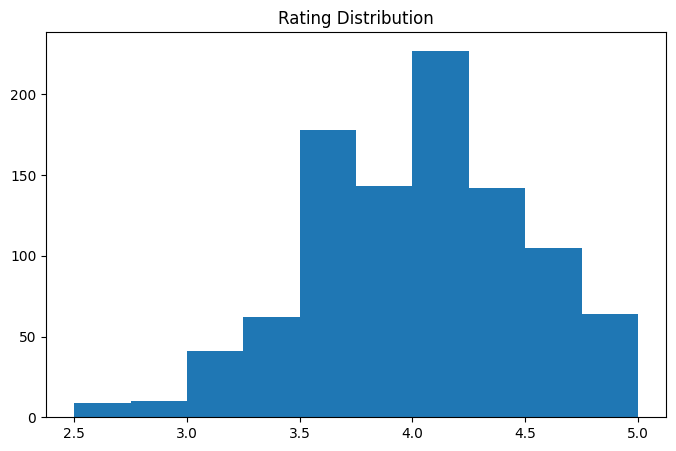

In [38]:
# Rating
plt.figure(figsize=(8,5))

plt.hist(df['Rating'])

plt.title("Rating Distribution")

plt.savefig("Rating Distribution")

plt.show()

Insights:

The histogram shows how customer ratings are distributed across products.
If most ratings are concentrated around 4–5, it indicates high customer satisfaction and positive product performance.

Recommendations:

Maintain the quality of highly rated products.
Identify products with low ratings and improve their quality or features.
Collect customer feedback regularly to improve overall ratings.

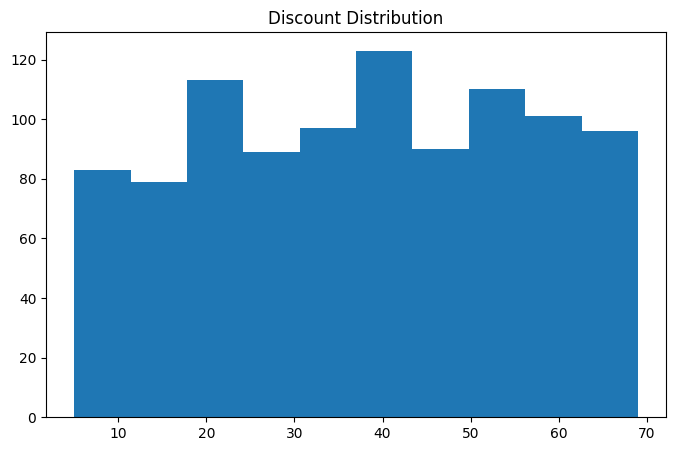

In [33]:
# Discount
plt.figure(figsize=(8,5))

plt.hist(df['Discount_Percentage'])

plt.title("Discount Distribution")
plt.savefig("Discount Distribution")
plt.show()


Insights:

The discount distribution shows how discounts are spread across products.
If most products have lower discount percentages, it suggests that products are sold near their original price while maintaining profitability.

Recommendations:

Offer attractive discounts for low-selling products to increase sales.
Avoid excessive discounts that may reduce profit margins.
Use seasonal or promotional discounts to attract more customers and improve engagement.

3. PIE CHART

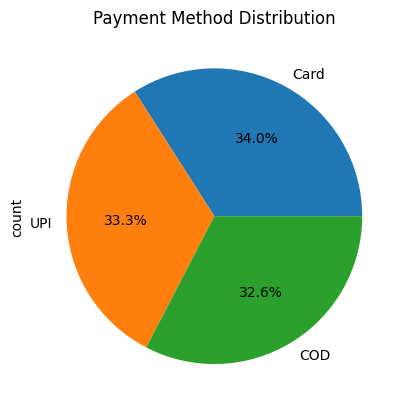

In [34]:
# Payment method
df['Payment_Method'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Payment Method Distribution")

plt.savefig("Payment Method Distribution")

plt.show()

Insights:

The pie chart shows the proportion of different payment methods used by customers.
The payment method with the highest percentage is the most preferred option among customers.

Recommendations:

Focus on improving and maintaining the most frequently used payment method.
Provide offers or cashback for less-used payment methods to increase usage.
Ensure secure and smooth payment processing to improve customer experience

4. BOX PLOT

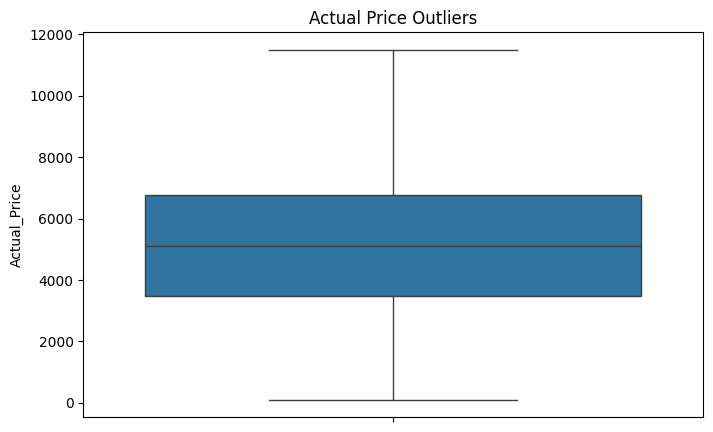

In [35]:
# For outliers
plt.figure(figsize=(8,5))

sns.boxplot(y=df['Actual_Price'])

plt.title("Actual Price Outliers")

plt.savefig("Actual Price Outliers")

plt.show()

Insights:

The boxplot helps identify outliers in the Actual_Price column.
Extreme price values indicate that some products are priced significantly higher or lower than the majority of products.

Recommendations:

Analyze outlier products separately to understand their pricing strategy.
Remove or treat unnecessary outliers if they negatively affect analysis results.
Use price segmentation to categorize premium and budget products effectively

5. HEATMAP CORRELATION

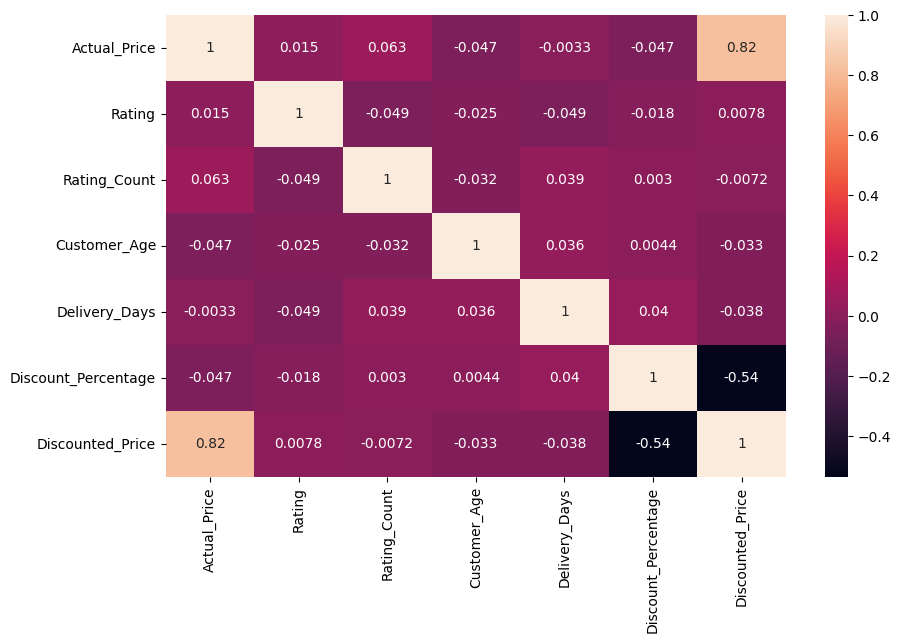

In [36]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True
)
plt.savefig("Heatmap")
plt.show()

Insights:

Positive (+) correlation values indicate that when one variable increases, the other variable also tends to increase.
Negative (-) correlation values indicate that when one variable increases, the other variable tends to decrease.
Values close to +1 indicate a strong positive relationship.
Values close to −1 indicate a strong negative relationship.
Values close to 0 indicate little or no relationship between variables.

Recommendations:

Focus on variables with strong positive relationships to improve business performance.
Analyze variables with strong negative relationships to identify possible issues.
Give more attention to factors that strongly influence customer behavior and sales.
Use correlation results for better decision-making and prediction analysis.